In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from src.data_preprocessing import load_processed
from src.model_training import train_neural_network
from src.visualization import plot_confusion_matrix

I0000 00:00:1781611645.439593   35803 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781611645.476546   35803 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781611646.435637   35803 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
X_train, X_test, y_train, y_test = load_processed()

## Train

In [3]:
model = train_neural_network(X_train, y_train)
print('Training complete.')

Epoch 1/20


/home/suman/miniforge3/envs/ml-system/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1781611648.422092   35803 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


5697/5697 ━━━━━━━━━━━━━━━━━━━━ 5s 822us/step - accuracy: 0.9990 - loss: 0.0063 - val_accuracy: 0.9994 - val_loss: 0.0036
Epoch 2/20
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 4s 785us/step - accuracy: 0.9994 - loss: 0.0031 - val_accuracy: 0.9994 - val_loss: 0.0029
Epoch 3/20
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 4s 733us/step - accuracy: 0.9994 - loss: 0.0028 - val_accuracy: 0.9994 - val_loss: 0.0028
Epoch 4/20
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 4s 777us/step - accuracy: 0.9994 - loss: 0.0025 - val_accuracy: 0.9993 - val_loss: 0.0034
Epoch 5/20
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 4s 787us/step - accuracy: 0.9994 - loss: 0.0025 - val_accuracy: 0.9994 - val_loss: 0.0030
Epoch 6/20
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 4s 783us/step - accuracy: 0.9995 - loss: 0.0022 - val_accuracy: 0.9994 - val_loss: 0.0031
Epoch 7/20
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 5s 949us/step - accuracy: 0.9995 - loss: 0.0021 - val_accuracy: 0.9994 - val_loss: 0.0028
Epoch 8/20
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 4s 782us/step - accuracy: 0.9995 - loss: 0.00

## Evaluate

In [4]:
y_prob = model.predict(X_test)
y_pred = (y_prob>0.5).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))


1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 364us/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.80      0.80      0.80        98

    accuracy                           1.00     56962
   macro avg       0.90      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962



## CONFUSION MATRIX

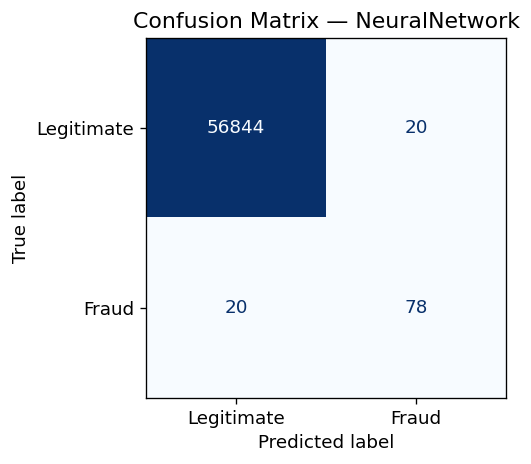

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix
from src.utils import RESULTS_DIR, ensure_results_dirs
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Fraud"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix — NeuralNetwork")
plt.tight_layout()
path = os.path.join(RESULTS_DIR, "confusion_matrices", f"Neural_Network.png")
fig.savefig(path)


## ROC-AUC curve

In [6]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [7]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

In [8]:
auc_score = roc_auc_score(
    y_test,
    y_prob
)

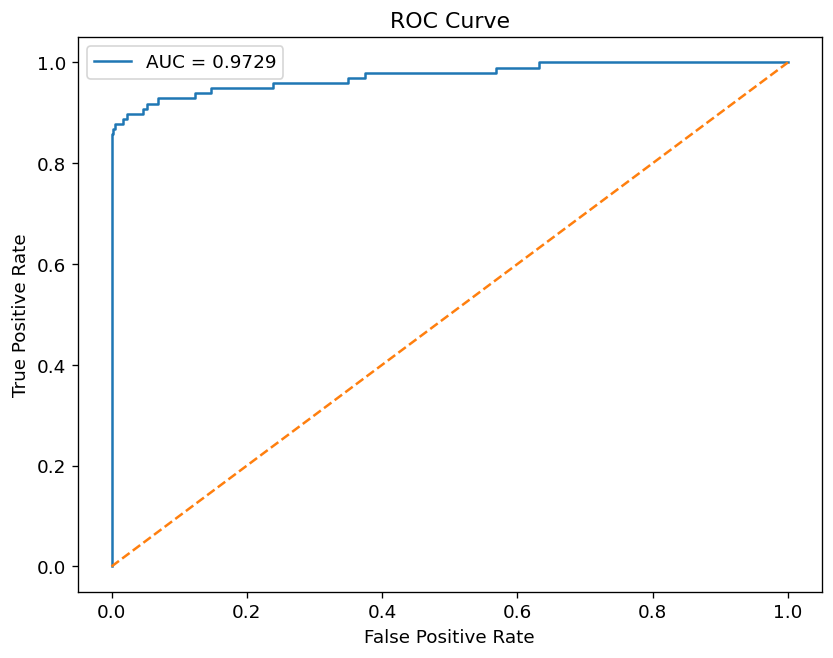

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

## Precision_Recall_Curve

In [10]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

In [11]:
precision, recall, thresholds = (
    precision_recall_curve(
        y_test,
        y_prob
    )
)


In [12]:
ap_score = average_precision_score(
    y_test,
    y_prob
)

FileNotFoundError: [Errno 2] No such file or directory: 'results/pr_curves/auprc_comparison_nn.png'

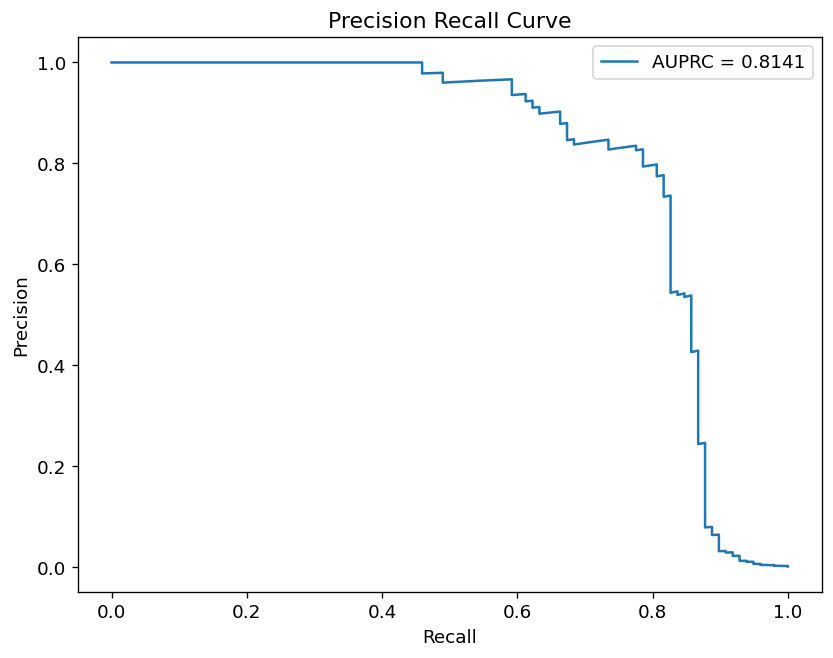

In [13]:
plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    label=f"AUPRC = {ap_score:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.legend()
plt.savefig("results/pr_curves/auprc_comparison_nn.png")
plt.show()
